<a href="https://colab.research.google.com/github/rapu23ece-png/HousePricePrediction_Raghavendra/blob/main/EmployeeAttrition_RaghavendraCPutani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("HR_Attrition.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df.shape
# The dataset contains 1470 employee records and 35 columns.

(1470, 35)

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [6]:
df['Attrition'].value_counts()
# Observation Most employees stayed with the company, while fewer employees left.

,count
Attrition,
No,1233
Yes,237


In [7]:
attrition_rate=(df['Attrition'].value_counts(normalize=True) * 100)
print(attrition_rate)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [8]:
# Observation:
# The dataset contains both numerical and categorical variables.
# Categorical features will need to be encoded before training machine learning models.
numeric_cols=df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols=df.select_dtypes(include=['object']).columns
print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


In [9]:
df.duplicated().sum()
# No duplicate records were found in the dataset.

np.int64(0)

In [10]:
categorical_cols=df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print("-"*40)


Attrition
['Yes' 'No']
----------------------------------------
BusinessTravel
['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
----------------------------------------
Department
['Sales' 'Research & Development' 'Human Resources']
----------------------------------------
EducationField
['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources']
----------------------------------------
Gender
['Female' 'Male']
----------------------------------------
JobRole
['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']
----------------------------------------
MaritalStatus
['Single' 'Married' 'Divorced']
----------------------------------------
Over18
['Y']
----------------------------------------
OverTime
['Yes' 'No']
----------------------------------------


In [11]:
for col in df.columns:
    if df[col].nunique()==1:
        print(col)

EmployeeCount
Over18
StandardHours


In [12]:
df=df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [13]:
binary_cols=['Attrition', 'Gender', 'OverTime']
for col in binary_cols:
    print(col)
    print(df[col].unique())
    print("-"*30)
df['Attrition']=df['Attrition'].map({'Yes':1, 'No':0})
df['Gender']=df['Gender'].map({'Male':1, 'Female':0})
df['OverTime']=df['OverTime'].map({'Yes':1, 'No':0})
df[['Attrition','Gender','OverTime']].head()
# Observation:
# Binary categorical columns (Attrition, Gender, and OverTime)
# were converted into numerical values using label mapping.
# This makes the data suitable for machine learning algorithms.

Attrition
['Yes' 'No']
------------------------------
Gender
['Female' 'Male']
------------------------------
OverTime
['Yes' 'No']
------------------------------


,Attrition,Gender,OverTime
0,1,0,1
1,0,1,0
2,1,1,1
3,0,0,1
4,0,1,0


In [14]:
categorical_cols=df.select_dtypes(include='object').columns
print(categorical_cols)
df=pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()
df.shape
# Observation:
# Multi-category categorical columns were converted into numerical
# format using One-Hot Encoding. The number of columns increased
# because each category was transformed into separate binary features.

Index(['BusinessTravel', 'Department', 'EducationField', 'JobRole',
       'MaritalStatus'],
      dtype='object')


(1470, 45)

In [15]:
import pandas as pd
df_eda = pd.read_csv("HR_Attrition.csv")
df_eda = df_eda.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'])
# Observation:
# A separate copy of the cleaned dataset is created for EDA.
# This keeps categorical values readable for analysis and visualization.

In [16]:
department_attrition = pd.crosstab(
    df_eda['Department'],
    df_eda['Attrition'],
    normalize='index'
) * 100
department_attrition

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


In [17]:
jobrole_attrition = pd.crosstab(
    df_eda['JobRole'],
    df_eda['Attrition'],
    normalize='index'
) * 100
jobrole_attrition
df_eda.groupby('Attrition')['MonthlyIncome'].describe()
pd.crosstab(
    df_eda['WorkLifeBalance'],
    df_eda['Attrition'],
    normalize='index'
) * 100
pd.crosstab(
    df_eda['YearsAtCompany'],
    df_eda['Attrition']
)

Attrition,No,Yes
YearsAtCompany,,
0,28,16
1,112,59
2,100,27
3,108,20
4,91,19
5,175,21
6,67,9
7,79,11
8,71,9


In [18]:
X=df.drop('Attrition',axis=1)
y=df['Attrition']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
# Observation:
# StandardScaler was applied after train-test splitting.
# The scaler was fitted only on the training data and then used to transform
# both the training and testing data, preventing data leakage.

In [21]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1176, 44)
X_test : (294, 44)
y_train: (1176,)
y_test : (294,)


In [22]:
# Model-1 Logistic Regression
from sklearn.linear_model import LogisticRegression
log_model=LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
print(y_pred_log[:10])

[0 0 0 0 1 1 0 0 0 0]


In [23]:
#Model-2 Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf=rf_model.predict(X_test)
print(y_pred_rf[:10])


[1 0 0 0 0 0 0 0 0 0]


In [24]:
#MOdel-3 Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
gb_model=GradientBoostingClassifier(
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb=gb_model.predict(X_test)
print(y_pred_gb[:10])

[0 0 0 0 0 0 0 0 0 0]


In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [26]:
# Logistic Regression Evaluation
print("===== Logistic Regression =====")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_log))
print("\nClassification Report")
print(classification_report(y_test, y_pred_log))

===== Logistic Regression =====
Accuracy : 0.7517006802721088
Precision: 0.34523809523809523
Recall   : 0.6170212765957447
F1 Score : 0.44274809160305345
ROC-AUC  : 0.6971746059092083

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [27]:
#Random Forest Evaluation
print("===== Random Forest =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_rf))
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====
Accuracy : 0.8333333333333334
Precision: 0.4
Recall   : 0.0851063829787234
F1 Score : 0.14035087719298245
ROC-AUC  : 0.5304074425015074

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294



In [28]:
#Gradient Boosting Evaluation
print("===== Gradient Boosting =====")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_gb))
print("\nClassification Report")
print(classification_report(y_test, y_pred_gb))

===== Gradient Boosting =====
Accuracy : 0.8503401360544217
Precision: 0.5882352941176471
Recall   : 0.2127659574468085
F1 Score : 0.3125
ROC-AUC  : 0.5922129382375743

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [29]:
# Observation:
# Gradient Boosting achieved the highest accuracy (85.03%) and precision,
# while Logistic Regression achieved the highest recall and ROC-AUC score.
# Since employee attrition prediction focuses on identifying employees at risk
# of leaving, Logistic Regression performed better for this business problem.

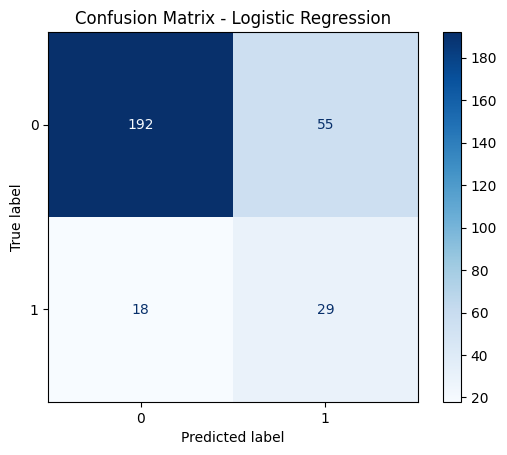

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
# Observation: The confusion matrix shows the number of correct and incorrect
# predictions made by the Logistic Regression model.

In [31]:
import pandas as pd
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(log_model.coef_[0])
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
35,JobRole_Laboratory Technician,0.810172
13,OverTime,0.771095
25,BusinessTravel_Travel_Frequently,0.722538
18,TotalWorkingYears,0.660270
8,JobLevel,0.650173
41,JobRole_Sales Representative,0.531090
26,BusinessTravel_Travel_Rarely,0.512780
29,EducationField_Life Sciences,0.512319
23,YearsSinceLastPromotion,0.499063
28,Department_Sales,0.470587


In [32]:
top10_features = feature_importance.head(10)
print(top10_features)
# The table shows the top 10 features that most strongly influence
# employee attrition according to the Logistic Regression model.

                             Feature  Importance
35     JobRole_Laboratory Technician    0.810172
13                          OverTime    0.771095
25  BusinessTravel_Travel_Frequently    0.722538
18                 TotalWorkingYears    0.660270
8                           JobLevel    0.650173
41      JobRole_Sales Representative    0.531090
26      BusinessTravel_Travel_Rarely    0.512780
29      EducationField_Life Sciences    0.512319
23           YearsSinceLastPromotion    0.499063
28                  Department_Sales    0.470587


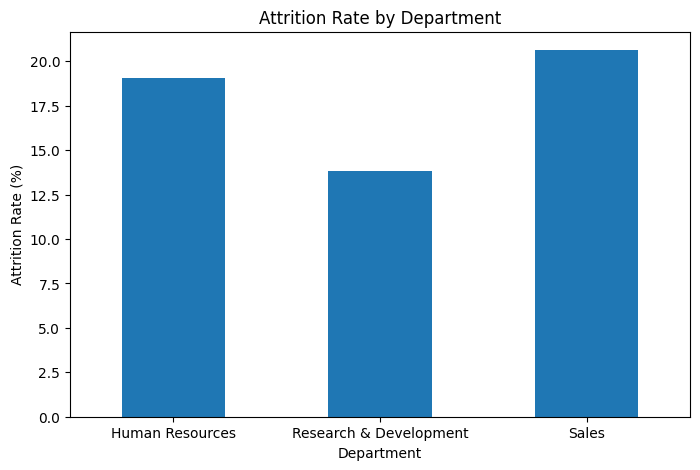

In [33]:
import matplotlib.pyplot as plt
department_attrition['Yes'].plot(kind='bar', figsize=(8,5))
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()
# This chart shows the percentage of employees leaving in each department.

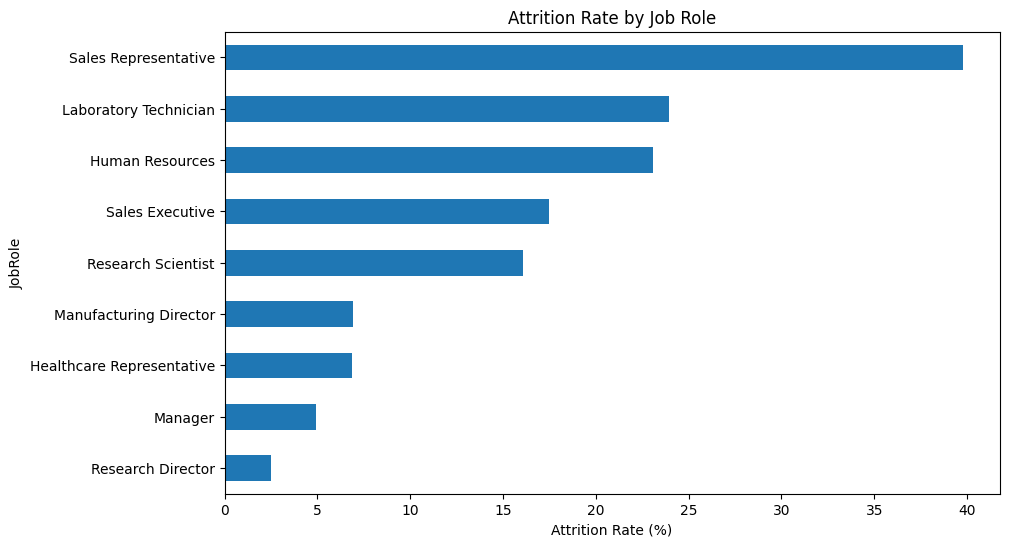

In [34]:
jobrole_attrition['Yes'].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.show()
#Job Role Attrition

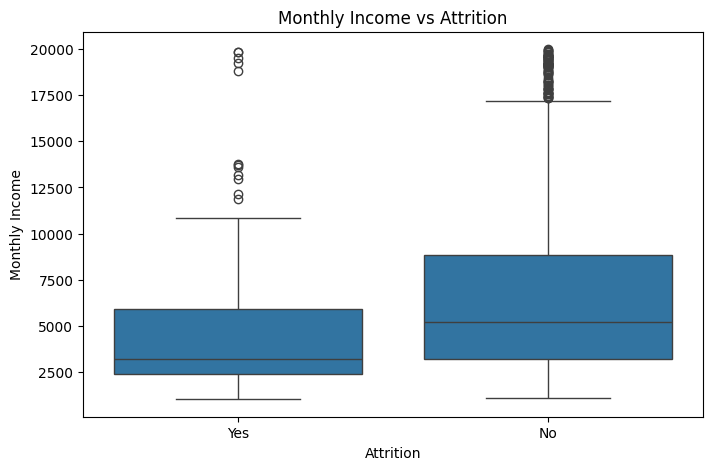

In [35]:
#Monthly Income vs Attrition (Box Plot)
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df_eda
)
plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()


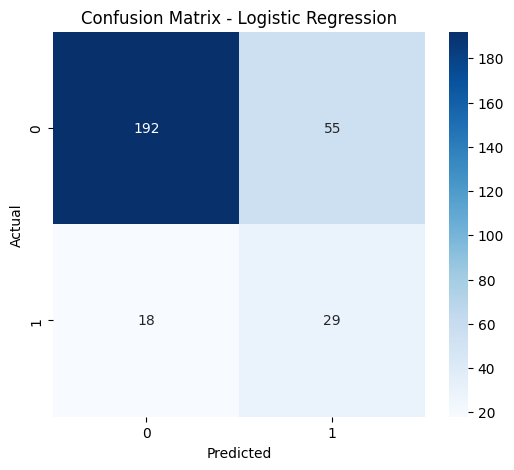

In [36]:
# Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred_log)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

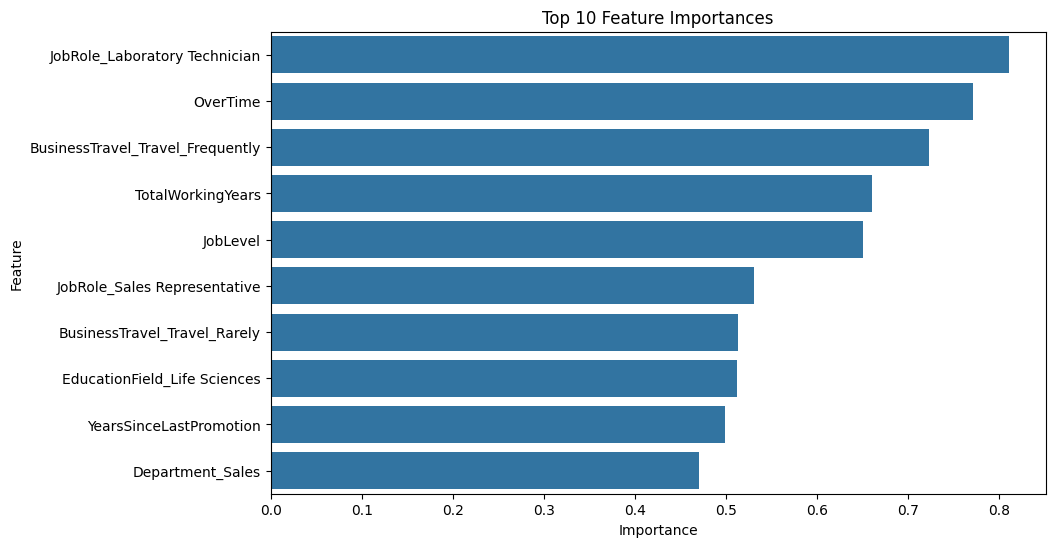

In [37]:
#Top 10 Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(
    data=top10_features,
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

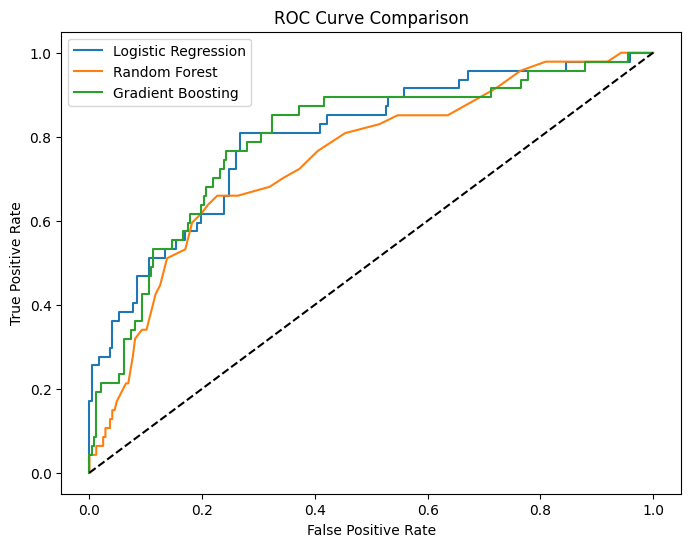

In [38]:
#ROC Curve
y_prob_log=log_model.predict_proba(X_test)[:,1]
y_prob_rf=rf_model.predict_proba(X_test)[:,1]
y_prob_gb=gb_model.predict_proba(X_test)[:,1]
from sklearn.metrics import roc_curve
fpr_log, tpr_log, _=roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ =roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ =roc_curve(y_test, y_prob_gb)
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# Business Insights

# 1. Sales Representatives showed the highest attrition rate,
# indicating that employees in sales-related roles are more likely to leave.

# 2. Employees who frequently worked overtime had a much higher chance
# of leaving, making overtime one of the strongest predictors of attrition.

# 3. Employees with lower monthly income generally showed higher attrition,
# suggesting that compensation may influence employee retention.

# 4. Frequent business travel and fewer total working years were among
# the important factors associated with employee attrition.

# 5. Logistic Regression performed best for this business problem because
# it achieved the highest Recall (0.617), making it more effective at
# identifying employees who are likely to leave.

In [ ]:
# Recommendations
# 1. Reduce excessive overtime by improving workload distribution.

# 2. Provide better career growth opportunities for employees
# in high-attrition job roles such as Sales Representatives.

# 3. Review compensation policies for employees with lower salaries.

# 4. Improve employee engagement programs for employees who travel
# frequently for business.

# 5. Use the trained Logistic Regression model as an early warning
# system to identify employees at risk of leaving and take
# preventive actions.

In [ ]:
# Conclusion

# The employee attrition dataset was successfully analyzed using
# data preprocessing, exploratory data analysis, and machine learning.
# Three classification models were developed and compared.
# Logistic Regression performed best for identifying employees
# at risk of attrition because of its higher recall score.
# Overtime, Job Role, Business Travel, Total Working Years,
# and Job Level were identified as the most influential factors.
# These insights can help HR departments improve employee retention
# through better workload management, compensation, and career development.